In [306]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [332]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [308]:
df = df[df['target'] != 0][['sepal width (cm)', 'petal length (cm)', 'target']]

In [309]:
df.head()

,sepal width (cm),petal length (cm),target
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [310]:
import seaborn as sns
import matplotlib.pyplot as plt

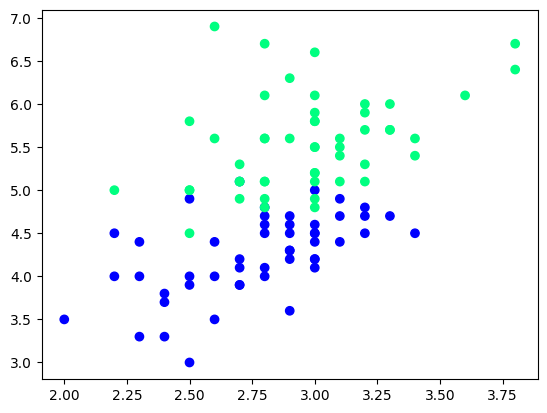

In [311]:
plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c=df['target'], cmap='winter')
plt.show()

In [312]:
df.train = df.iloc[:60,:].sample(10)
df.train

C:\Users\ACER\AppData\Local\Temp\ipykernel_22036\1339978991.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.train = df.iloc[:60,:].sample(10)


,sepal width (cm),petal length (cm),target
100,3.3,6.0,2
107,2.9,6.3,2
85,3.4,4.5,1
88,3.0,4.1,1
99,2.8,4.1,1
74,2.9,4.3,1
80,2.4,3.8,1
72,2.5,4.9,1
81,2.4,3.7,1
108,2.5,5.8,2


In [313]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [314]:
df_train

,sepal width (cm),petal length (cm),target
137,3.1,5.5,2
78,2.9,4.5,1
81,2.4,3.7,1
118,2.6,6.9,2
60,2.0,3.5,1
84,3.0,4.5,1
100,3.3,6.0,2
67,2.7,4.1,1
63,2.9,4.7,1
103,2.9,5.6,2


In [315]:
df_test

,sepal width (cm),petal length (cm),target
71,2.8,4.0,1
142,2.7,5.1,2
62,2.2,4.0,1
68,2.2,4.5,1
98,2.5,3.0,1


In [316]:
df_val

,sepal width (cm),petal length (cm),target
144,3.3,5.7,2
93,2.3,3.3,1
101,2.7,5.1,2
56,3.3,4.7,1
147,3.0,5.2,2


In [317]:
X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

In [318]:
y_test

array([2, 1, 2, 1, 2])

### Bagging - Training

In [319]:
# Data for Tree 1

df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal width (cm),petal length (cm),target
100,3.3,6.0,2
118,2.6,6.9,2
67,2.7,4.1,1
103,2.9,5.6,2
81,2.4,3.7,1
103,2.9,5.6,2
63,2.9,4.7,1
78,2.9,4.5,1


In [320]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [321]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

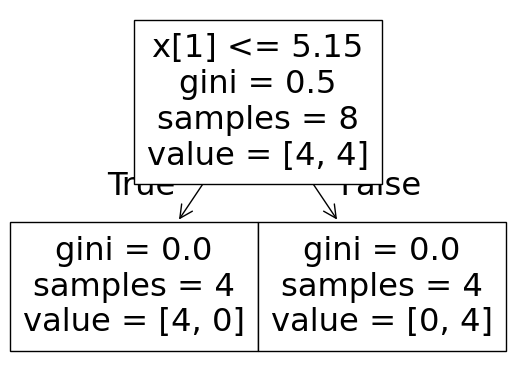

0.8


C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


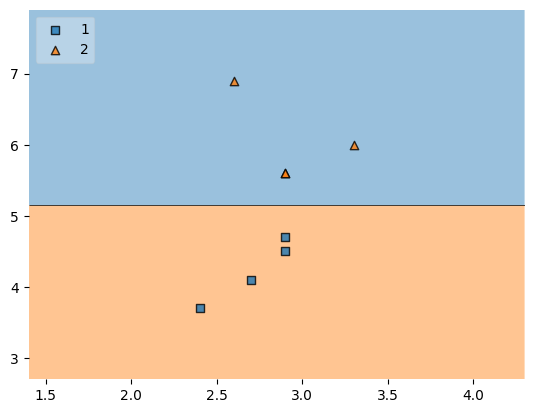

In [322]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1, X, y)

In [323]:
# Data for Tree 2

df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal width (cm),petal length (cm),target
103,2.9,5.6,2
118,2.6,6.9,2
103,2.9,5.6,2
84,3.0,4.5,1
84,3.0,4.5,1
81,2.4,3.7,1
118,2.6,6.9,2
81,2.4,3.7,1


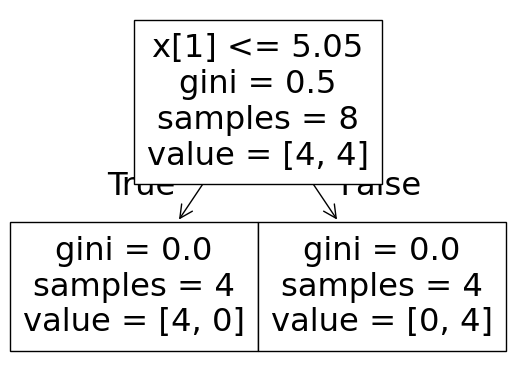

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


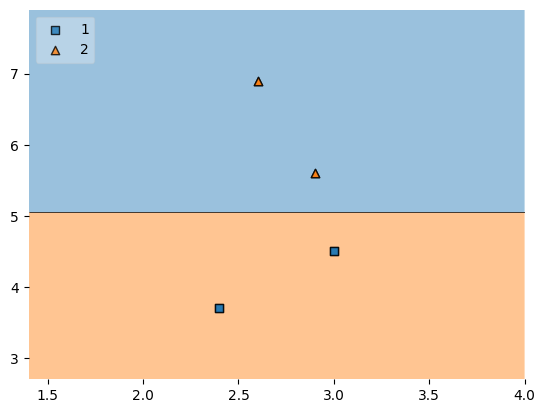

In [324]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X, y)

In [325]:
# Data for Tree 3

df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,sepal width (cm),petal length (cm),target
103,2.9,5.6,2
67,2.7,4.1,1
118,2.6,6.9,2
81,2.4,3.7,1
78,2.9,4.5,1
81,2.4,3.7,1
103,2.9,5.6,2
60,2.0,3.5,1


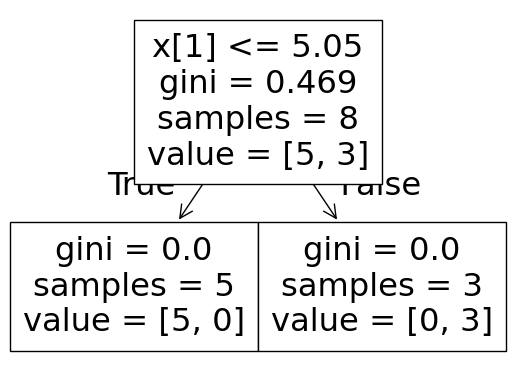

1.0


C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


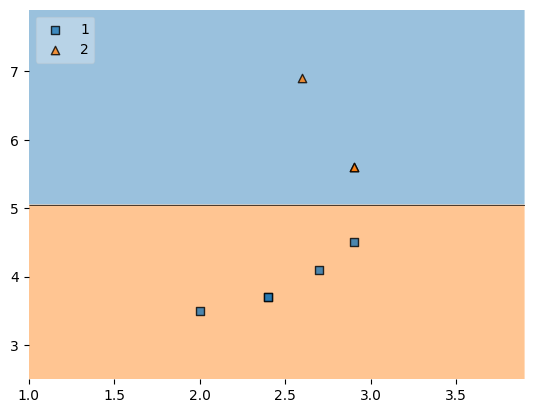

In [326]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, X, y)

### Bagging - Predict

In [327]:
df_test

,sepal width (cm),petal length (cm),target
71,2.8,4.0,1
142,2.7,5.1,2
62,2.2,4.0,1
68,2.2,4.5,1
98,2.5,3.0,1


In [328]:
print("Predictor 1", dt_bag1.predict(np.array([3.0, 6.4]).reshape(1,2)))
print("Predictor 1", dt_bag2.predict(np.array([3.0, 6.4]).reshape(1,2)))
print("Predictor 1", dt_bag3.predict(np.array([3.0, 6.4]).reshape(1,2)))

Predictor 1 [2]
Predictor 1 [2]
Predictor 1 [2]


C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Pasting

In [329]:
# Row Sampling without Replacement

df_train

,sepal width (cm),petal length (cm),target
137,3.1,5.5,2
78,2.9,4.5,1
81,2.4,3.7,1
118,2.6,6.9,2
60,2.0,3.5,1
84,3.0,4.5,1
100,3.3,6.0,2
67,2.7,4.1,1
63,2.9,4.7,1
103,2.9,5.6,2


In [330]:
df_train.sample(8)

,sepal width (cm),petal length (cm),target
137,3.1,5.5,2
81,2.4,3.7,1
63,2.9,4.7,1
60,2.0,3.5,1
84,3.0,4.5,1
100,3.3,6.0,2
118,2.6,6.9,2
103,2.9,5.6,2


### Random SubSpaces

In [333]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [335]:
df1 = df.sample(10)
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
66,5.6,3.0,4.5,1.5,1
104,6.5,3.0,5.8,2.2,2
10,5.4,3.7,1.5,0.2,0
146,6.3,2.5,5.0,1.9,2
4,5.0,3.6,1.4,0.2,0
121,5.6,2.8,4.9,2.0,2
43,5.0,3.5,1.6,0.6,0
138,6.0,3.0,4.8,1.8,2
147,6.5,3.0,5.2,2.0,2


In [340]:
df1.sample(2, replace=True, axis=1)

,sepal width (cm),petal width (cm)
100,3.3,2.5
66,3.0,1.5
104,3.0,2.2
10,3.7,0.2
146,2.5,1.9
4,3.6,0.2
121,2.8,2.0
43,3.5,0.6
138,3.0,1.8
147,3.0,2.0


### Random Patches

In [341]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
66,5.6,3.0,4.5,1.5,1
104,6.5,3.0,5.8,2.2,2
10,5.4,3.7,1.5,0.2,0
146,6.3,2.5,5.0,1.9,2
4,5.0,3.6,1.4,0.2,0
121,5.6,2.8,4.9,2.0,2
43,5.0,3.5,1.6,0.6,0
138,6.0,3.0,4.8,1.8,2
147,6.5,3.0,5.2,2.0,2


In [344]:
df1.sample(5, replace=True).sample(2, replace=True, axis=1)

,sepal length (cm),sepal length (cm)
138,6.0,6.0
138,6.0,6.0
66,5.6,5.6
104,6.5,6.5
43,5.0,5.0
